In [1]:
print("""
@File         : window_operations.ipynb
@Author(s)    : Stephen CUI
@LastEditor(s): Stephen CUI
@CreatedTime  : 2025-01-04 23:07:16
@Email        : cuixuanstephen@gmail.com
@Description  : 窗口操作
""")


@File         : window_operations.ipynb
@Author(s)    : Stephen CUI
@LastEditor(s): Stephen CUI
@CreatedTime  : 2025-01-04 23:07:16
@Email        : cuixuanstephen@gmail.com
@Description  : 窗口操作



In [2]:
import pandas as pd

窗口操作允许计算值的滑动分区（或“窗口”）上的值。通常，这些操作用于计算诸如“滚动 90 天平均值”之类的内容，但它们足够灵活，可以扩展到任何算法。

虽然从技术上讲，窗口操作并非分组操作，但为它们共享类似的 API 并处理“数据组”。窗口操作与分组操作调用的唯一区别在于，窗口操作不是通过唯一值集形成组，而是通过迭代 pandas 对象的每个值并查看特定数量的前一个值（有时是后一个值）来创建组。

In [3]:
ser = pd.Series([0, 1, 2, 4, 8, 16],
                dtype=pd.Int64Dtype())

ser

0     0
1     1
2     2
3     4
4     8
5    16
dtype: Int64

通过 `pd.Series.rolling` 方法访问。调用此方法时，需要告诉 pandas 所需的窗口大小 `n`。pandas 库从每个元素开始，向后查找 `n‑1` 条记录以形成“窗口”：

In [4]:
ser.rolling(2).sum()

0     NaN
1     1.0
2     3.0
3     6.0
4    12.0
5    24.0
dtype: float64

> 注意到，我们一开始使用的是 `pd.Int64Dtype()`，但在滚动窗口操作之后，最终得到的是 float64 类型。不幸的是，pandas 窗口操作在至少 2.2 版的 pandas 扩展系统中无法很好地运行（请参阅问题 #50449），因此暂时我们需要将结果转换回正确的数据类型：

![Rolling window with sum aggregation](../../IMAGES/FIG8-3.png)

对于我们的第一个记录，由于它无法形成一个包含两个元素的窗口，因此 pandas 返回一个缺失值。如果希望滚动计算只对尽可能多的元素求和，即使无法达到窗口大小，也可以将一个参数传递给 `min_periods=`，该参数指示执行聚合所需的每
个窗口内的最小元素数：

In [5]:
ser.rolling(2, min_periods=1).sum()

0     0.0
1     1.0
2     3.0
3     6.0
4    12.0
5    24.0
dtype: float64

默认情况下，滚动窗口操作会向后查看以尝试满足您的窗口大小要求。你也可以将它们“居中”，以便 pandas 既能向前看，又能向后看。

In [6]:
ser.rolling(3, center=True).sum().astype(pd.Int64Dtype())

0    <NA>
1       3
2       7
3      14
4      28
5    <NA>
dtype: Int64

另一种类型的窗口函数是“扩展窗口”，它查看遇到的所有先前值。它的语法很简单；只需将对 `pd.Series.rolling` 的调用替换为 `pd.Series.expanding`，然后使用所需的聚合函数。扩展求和类似于您之前见过的 `pd.Series.cumsum` 方法，因此出于演示目的，让我们选择一个不同的聚合函数，例如平均值：

> 虽然至今的函数可以使用 `cummax` 或者 `cummin`，但是一次性求多个可以使用 `expanding().agg(functionList)` 使得更加简洁。

In [7]:
ser.expanding().mean().astype(pd.Float64Dtype())

0         0.0
1         0.5
2         1.0
3        1.75
4         3.0
5    5.166667
dtype: Float64

group by 和滚动/扩展窗口函数可以非常自然地处理时间数据，可以简洁地执行计算，例如“N 天移动平均值”、“年初至今 X”、“季度至今 X”等。

In [8]:
df = pd.read_csv(
    '../../DATA/NVDA.csv',
    usecols=['Date', 'Close'],
    parse_dates=['Date'],
    dtype_backend='numpy_nullable'
).set_index('Date')

df

,Close
Date,
2020-01-02,59.977501
2020-01-03,59.017502
2020-01-06,59.264999
2020-01-07,59.982498
2020-01-08,60.095001
...,...
2023-12-22,488.299988
2023-12-26,492.790009
2023-12-27,494.170013


In [9]:
import matplotlib.pyplot as plt

plt.ion()

<Axes: xlabel='Date'>

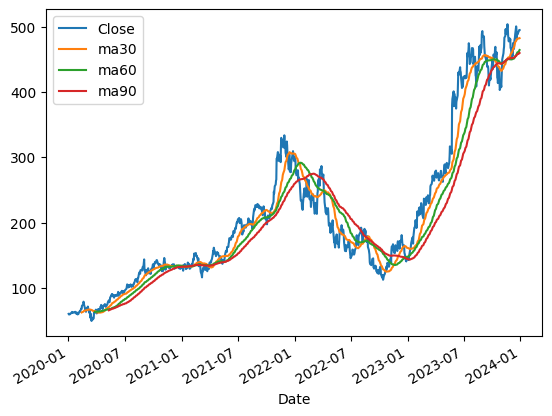

In [11]:
df.assign(
    ma30=df['Close'].rolling(30).mean().astype(pd.Float64Dtype()),
    ma60=df['Close'].rolling(60).mean().astype(pd.Float64Dtype()),
    ma90=df['Close'].rolling(90).mean().astype(pd.Float64Dtype()),
).plot()

In [13]:
df.groupby(pd.Grouper(freq='YS')).expanding().agg(
    ['min', 'max', 'mean']
)

Close                        
                              min         max        mean
Date       Date                                          
2020-01-01 2020-01-02   59.977501   59.977501   59.977501
           2020-01-03   59.017502   59.977501   59.497501
           2020-01-06   59.017502   59.977501   59.420001
           2020-01-07   59.017502   59.982498   59.560625
           2020-01-08   59.017502   60.095001   59.667500
...                           ...         ...         ...
2023-01-01 2023-12-22  142.649994  504.089996  363.600610
           2023-12-26  142.649994  504.089996  364.123644
           2023-12-27  142.649994  504.089996  364.648024
           2023-12-28  142.649994  504.089996  365.172410
           2023-12-29  142.649994  504.089996  365.692600

[1006 rows x 3 columns]

<Axes: xlabel='Date'>

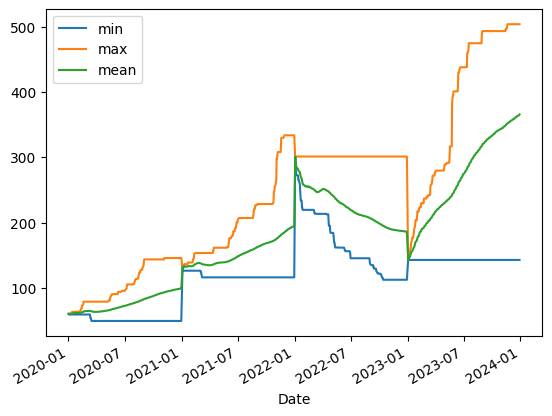

In [16]:
df.groupby(pd.Grouper(freq='YS')).expanding().agg(
    ['min', 'max', 'mean']
).droplevel(axis='columns', level=0).reset_index(level=0, drop=True).plot()

<Axes: xlabel='Date'>

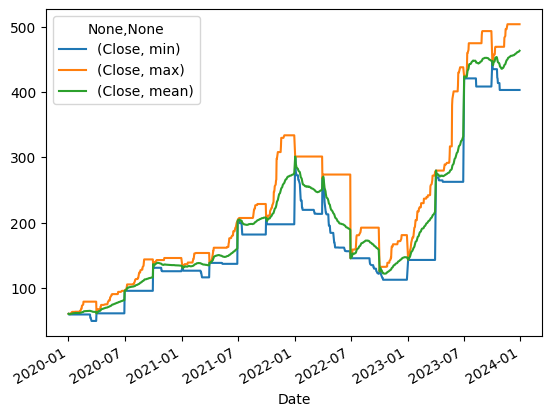

In [18]:
df.groupby(pd.Grouper(freq='QS')).expanding().agg(
    ['min', 'max', 'mean']
).reset_index(level=0, drop=True).plot()

<Axes: xlabel='Date'>

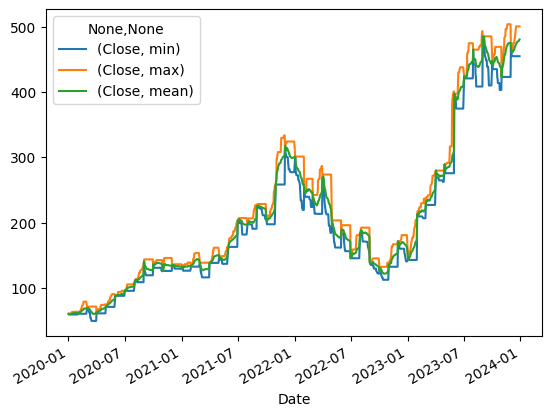

In [19]:
df.groupby(pd.Grouper(freq='MS')).expanding().agg(
    ['min', 'max', 'mean']
).reset_index(level=0, drop=True).plot()